In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_vendas = pd.read_csv('01.amazon_sales_dataset.csv')
df_vendas.columns

In [ ]:
df_vendas.dtypes

In [ ]:
df_vendas.info()

In [ ]:
coluna_alvo = 'total_sales'

# Medidas de Tendencia Centrais
total_vendas = df_vendas[coluna_alvo].sum()
media_valor_vendas = df_vendas[coluna_alvo].mean()
venda_minima = df_vendas[coluna_alvo].min()
venda_maxima = df_vendas[coluna_alvo].max()

In [ ]:
# Medidas de Posição
q1 = np.percentile(df_vendas[coluna_alvo], 25)
# q2 = Mediana
q2 = np.percentile(df_vendas[coluna_alvo], 50)
q3 = np.percentile(df_vendas[coluna_alvo], 75)

In [ ]:
# avaliar a 'confiabilidade' da média
delta_media_mediana = media_valor_vendas - q2
distancia_percentual = media_valor_vendas/q2
# Caso 1. Distancia <= 10% (0.9 ~ 1.1)
# R = Média é altamente confiavel
# Caso 2. Distancia entre 10% e 25% 
# (0.75~0.9 / 1.10~1.25)
# R = Média sofre influencia moderada de extremos
# Caso 3. Distancia > 25% (< 0.75 / > 1.25)
# R = NÃO confie na média, ela é distorcida 
# pelos extremos


In [ ]:
# Medidas de Dispersão

# 1. Amplitude
amplitude = venda_maxima - venda_minima

# 2. Variancia e Desvio Padrão
# Medem a distancia média dos pontos até a Média
# Se for um valor alto -> Maior volatilidade
variancia = df_vendas[coluna_alvo].var()
desvio_padrao = df_vendas[coluna_alvo].std()

# 3.IQR -> 50% 'internos' dos dados (25%~75%)
# Muito robusto a ouliers
iqr = q3 - q1

# 4. Coeficiente de Variação (CV)
# Muito usado para comparar volatilidades 
# de 'grandezas' diferentes (colunas diferentes)
# Obs.: Multiplicado por 100 para ser descrito como porcentagem
cv = (desvio_padrao/media_valor_vendas)*100

In [ ]:
# Assimetria (Skewness)
assimetria = df_vendas[coluna_alvo].skew()

# Caso 1. Assimetria entre -0.5 e 0.5
# R = Dados Equilibrados
# Caso 2. Assimetria > 0.5 (Positiva)
# R = Valores altos são raros, porém são tão
# grandes que distorcem o calculo
# Caso 3. Assimetria < - 0.5 (Negativa)
# R = Menos valores distorcem o calculo para baixo

# Kurtosis (curtose)
# Mede o 'peso' das caudas -> 
# frequencia e gravidade dos outliers
curtose = df_vendas[coluna_alvo].kurtosis()

In [ ]:
print('\n--- Resumo Executivo de Vendas ---')
print(f'1. Volume Total (Soma das Vendas): \
      $ {total_vendas:,.2f}')
# Representa o tamanho total da nossa operação no periodo
print(f'2. Gasto Médio: $ {media_valor_vendas:,.2f}')
# Valor esperado que um cliente gaste em média conosco
print(f'3. Maior Venda: $ {venda_maxima:,.2f}')
# Nosso recorde. Investigar o perfil do cliente
print(f'4. Menor Venda: $ {venda_minima:,.2f}')
# Menor valor registrado. Investigar se há anomalias ou fraude


In [ ]:
print('--- Relatorio Estatísticos de Negócio ---')

print(f'A média de vendas é \
      $ {media_valor_vendas:,.2f}')
print(f'A mediana (valor central) das vendas é \
      $ {q2:,.2f}')
print(f'O Delta (Diferença Financeira) entre \
      elas é: $ {delta_media_mediana:,.2f}')

print('\n--- Analise Comportamental ---\n')
print(f'Distância Relativa entre elas: \
      {distancia_percentual:.2f}')


if abs(distancia_percentual-1) < 0.10:
      print(f'INFERÊNCIA: Baixa Dispersão. \
            A média é confiável para representar a coluna.')

elif abs(distancia_percentual-1) < 0.25:
      print(f'INFERÊNCIA: Dispersão Moderada. \
            Fique atento aos extremos, média começa a mentir.')
      
else:
      print(f'INFERÊNCIA: Alta Dispersão. \
            A média NÃO é confiável, foque na mediana.')

print(f'Grau de Assimetria (Skewness): \
      {assimetria:.4f}')

if assimetria > 0.5:
    print(f'INFERÊNCIA (Assimetria Positiva): \
            Nossas vendas tem uma cauda longa para a direita.\
            Os grandes clientes são minoria, todavia eles \
            faturam valores expressivos \
            puxando a venda média para cima')
elif assimetria < -0.5:
    print(f'INFERÊNCIA (Assimetria Negativa): \
            Nossa vendas tem uma cauda longa para a esquerda.\
            O valor médio está sendo puxado para baixo por um \
            grande volume de vendas baratas, \
            talvez pela liquidação')
else:
    print(f'INFERÊNCIA (Simétrica): Distribuição Equilibrada.\
          Média e mediana estão bem próximas.')


In [ ]:
print(f'--- Dispersão ---')
print(f'Amplitude Total: $ {amplitude:.2f}')
# Amplitude no negócio: Diferença entre a maior e menor venda
print(f'Desvio Padrão: $ {desvio_padrao:.2f}')
# Desvio no negócio: Nível de dispersão dos valores de venda
print(f'Coeficiente de Variação: {cv:.2f}%')
if cv > 30:
    print('INFERÊNCIA: Volatilidade Alta.\
          Não há consistencia no faturamento diario')
else:
    print('INFERÊNCIA: Volatidade Baixa.\
          Vendas são consistentes e prevísiveis.')

print(f'Intervalo Interquartil (IQR): ${iqr:,.2f}')
print('INFERÊNCIA: Esta é a variação de gastos do nosso' \
'consumidor padrão, ignorando clientes que compram muito pouco' \
'ou valores muito altos')

# Curtose -> Curva Normal (Curtose = 3)
# Curtose no Pandas -> Já trata do Excesso sobre a curva normal
# No Pandas .kurtosis() = 0 -> Mesocúrtica
print(f'Curtose (Excesso - Fisher): {curtose:.4f}')
if curtose > 0.5:
    print('INFERÊNCIA: Distribuição Leptocúrtica' \
    '(Pico agudo, caudas grossas)')
    print('Sobre o negócio: A maioria das vendas estão no ' \
    'centro, todavia temos uma altissima probabilidade' \
    'de eventos extremos (outliers)')
elif curtose < -0.5:
    print(f'INFERÊNCIA: Distribuição Platicúrtica \
          (Pico suave (achatado), caudas finas)')
    print('Sobre o negócio: AS vendas estão muito bem ' \
    'distribuidas, chance baixa de ter ' \
    'eventos extremos (outliers)')
else:
    print(f'INFERÊNCIA: Distribuição Mesocúrtica \
          (picos medianos, caudas normal)')
    print('Sobre negócio: Comportamento Normal e' \
    'totalmente previsível')



In [ ]:
# Navegação e Filtros Avançados

# iloc -> pega 'n' linhas -> indice
amostra = df_vendas.iloc[0:10]
amostra

In [ ]:
# loc -> usa o nome da coluna e filtra com base em algo

# Quem são os melhores clientes?
clientes_vip = df_vendas.loc[df_vendas['total_sales'] > q3]
clientes_vip

clientes_vip2 = df_vendas.loc[df_vendas['total_sales'] > q3,
    ['order_id', 'customer_name', 'category', 'total_sales']]
clientes_vip2

In [ ]:
# query (consulta)

# O gerente quer saber quais pedidos da categoria Eletronico
# ficaram acima da média geral
filtro = \
f"category == 'Electronics' and total_sales > {media_valor_vendas}"
eletronicos = df_vendas.query(filtro)
eletronicos

In [31]:
# df_vendas é a base
# agrupar por qual coluna? category
# o que iremos calcular? total_sales

df_categoria_agrupada = \
df_vendas.groupby('category')['total_sales'] \
.sum().reset_index()

df_categoria_ordenada = \
df_categoria_agrupada.sort_values(
    by='total_sales',ascending=False)

print(df_categoria_ordenada)
pd.set_option(
    'display.float_format', lambda x:'%.2f'% x)



      category  total_sales
0  Electronics 219356274.74
2         Home 214763766.06
1      Fashion 208009064.75


In [ ]:
import matplotlib.pyplot as plt

<BarContainer object of 3 artists>

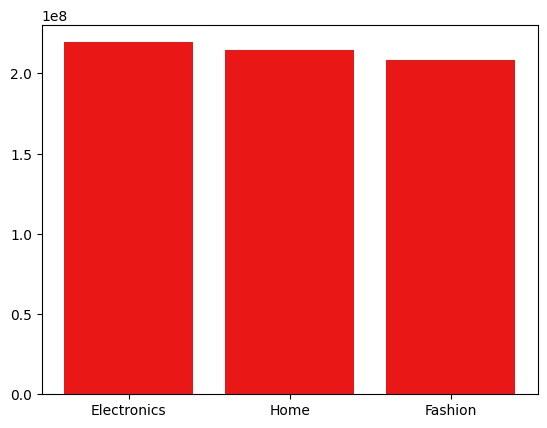

In [32]:
plt.bar(df_categoria_ordenada['category'],
        df_categoria_ordenada['total_sales'],
        color="#ea1717ff")